# Finding Donors for *CharityML*

In this project, we will test out several supervised algorithms to accurately model individuals' income using data collected from the 1994 U.S. Census. We will then choose the best candidate algorithm from preliminary results and further optimise this algorithm to best model the data. Our goal with this implementation is to construct a model that accurately predicts whether an individual makes more than $50,000. This sort of task can arise in a non-profit setting, where organisations survive on donations.  Understanding an individual's income can help a non-profit better understand how large of a donation to request, or whether or not they should reach out to begin with.  While it can be difficult to determine an individual's general income bracket directly from public sources, we can infer this value from other publicly available features. 

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income). The dataset was donated by Ron Kohavi and Barry Becker, after being published in the article _"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"_. You can find the article by Ron Kohavi [online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf). The data we investigate here consists of small changes to the original dataset, such as removing the `'fnlwgt'` feature and records with missing or ill-formatted entries.

## Learning Objectives

At the end of this notebook, you should be able to:

- Preprocess mixed census data with log transforms, one-hot encoding, and feature scaling.
- Establish a naive baseline and choose an appropriate evaluation metric (the F-beta score).
- Compare a Decision Tree and an AdaBoost classifier on accuracy and F-score.
- Tune the strongest model with grid search and assess the effect of reducing the feature set.

----
## Exploring the Data

Let's start with importing the necessary libraries, reading in the data, and checking out the dataset.

Note that the last column from this dataset, `'income'`, will be our target label (whether an individual makes more than, or at most, $50,000 annually). All other columns are features about each individual in the census database.

In [1]:
# Import libraries necessary for this project
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Import functions from our Python file (see visuals_script.py in the repo)
import visuals_script as vs

# Pretty display for notebooks
%matplotlib inline

sns.set(style="whitegrid", color_codes=True)

# Ignore warnings
warnings.filterwarnings("ignore")

Let's start by importing the dataset and examining the first few rows. 

In [2]:
# Load the Census dataset
data = pd.read_csv("data/census.csv")
data.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [3]:
# Examine the datatypes
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  str    
 2   education_level  45222 non-null  str    
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  str    
 5   occupation       45222 non-null  str    
 6   relationship     45222 non-null  str    
 7   race             45222 non-null  str    
 8   sex              45222 non-null  str    
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  str    
 13  income           45222 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 4.8 MB


A simple investigation of the dataset can determine how many individuals fit into either group, and tell us about the percentage of these individuals making more than \$50,000. 

Let's take a look at the following: 

- The total number of records, `'n_records'`
- The number of individuals making more than \$50,000 annually, `'n_greater_50k'`.
- The number of individuals making at most \$50,000 annually, `'n_at_most_50k'`.
- The percentage of individuals making more than \$50,000 annually, `'greater_percent'`.

In [4]:
# TODO: Total number of records
n_records = len(data)

# TODO: Number of records where individual's income is more than $50,000
n_greater_50k = len(data[data["income"] == ">50K"])

# TODO: Number of records where individual's income is at most $50,000
n_at_most_50k = len(data[data["income"] == "<=50K"])

# TODO: Percentage of individuals whose income is more than $50,000
greater_percent = 100 * n_greater_50k / n_records

# Print the results
print ("Total number of records: {}".format(n_records))
print ("Individuals making more than $50,000: {}".format(n_greater_50k))
print ("Individuals making at most $50,000: {}".format(n_at_most_50k))
print ("Percentage of individuals making more than $50,000: {:.2f}%".format(greater_percent))

Total number of records: 45222
Individuals making more than $50,000: 11208
Individuals making at most $50,000: 34014
Percentage of individuals making more than $50,000: 24.78%


We can also visualise the relationship between different features of an individual, and their incomes.

Let's see breakdown of the counts of people earning above or below 50K based on their sex and education levels.

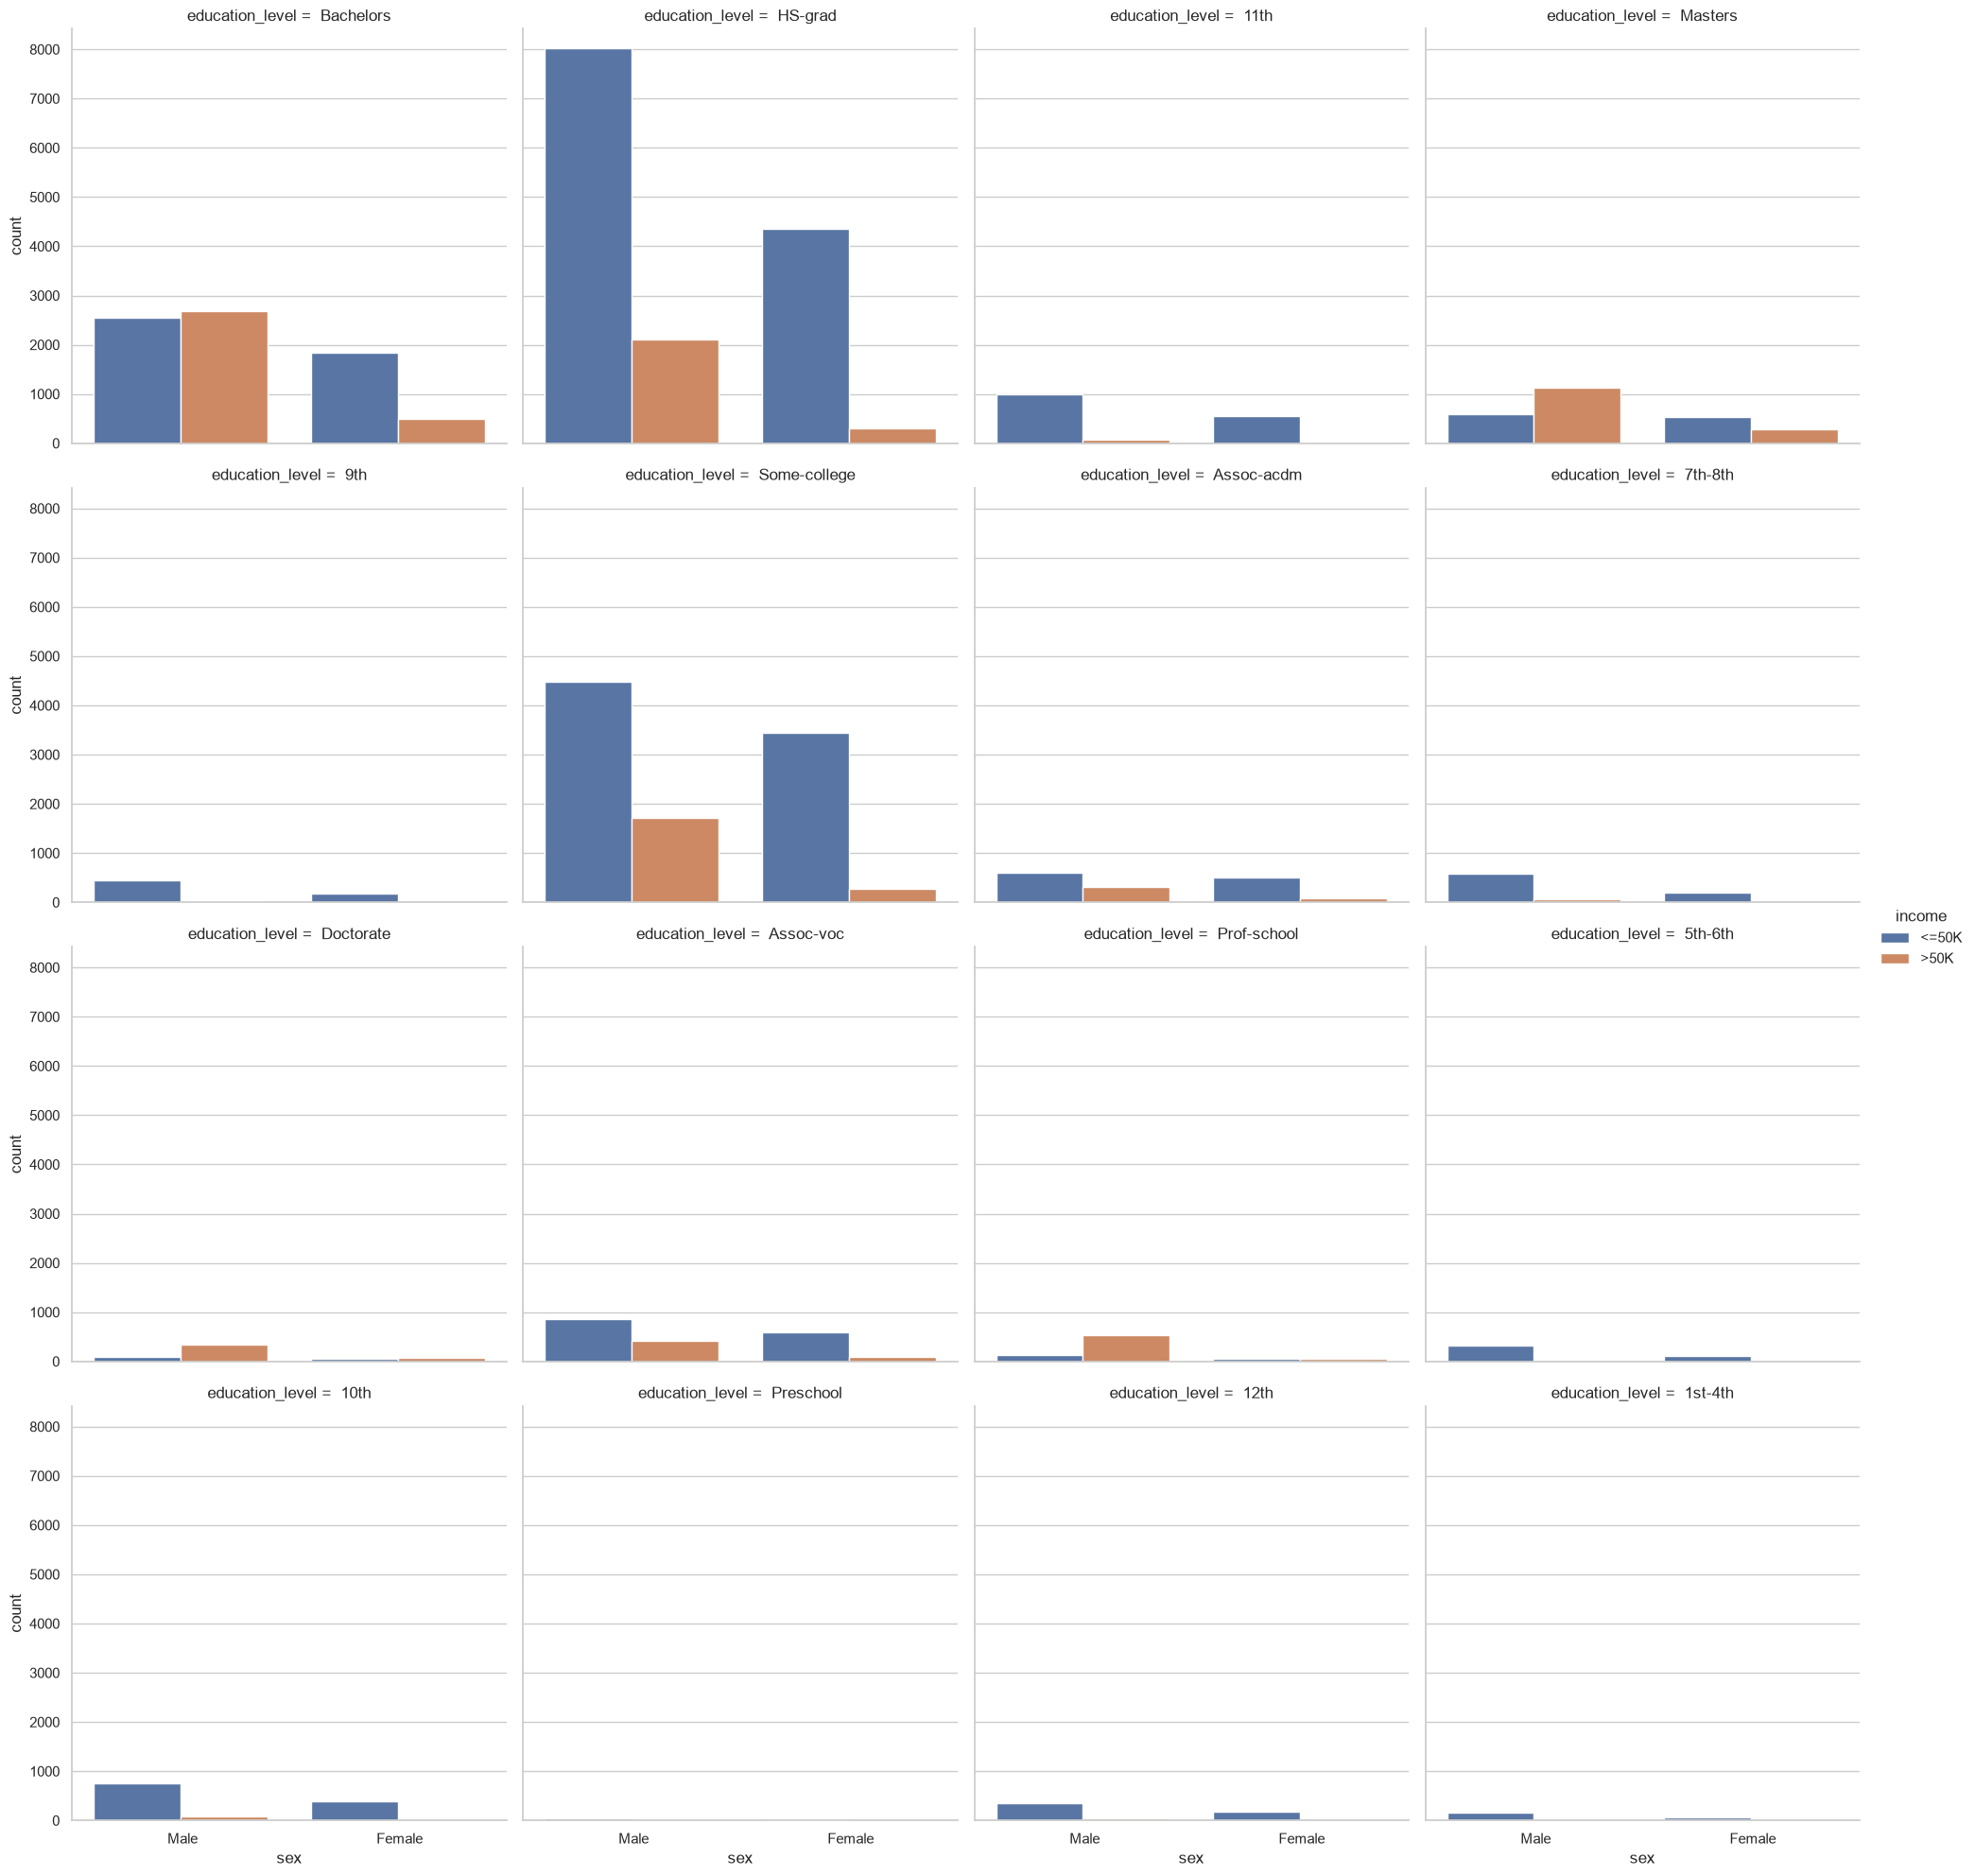

In [5]:
# One way to visualise the relationship is by using a seaborn catplot
sns.catplot(x="sex", col="education_level", data=data, hue="income", kind="count", col_wrap=4);

----
## Preparing the Data
Before data can be used as input for machine learning algorithms, it often must be cleaned, formatted, and restructured, which is typically known as **preprocessing**. Fortunately, for this dataset, there are no invalid or missing entries we must deal with, however, there are some qualities about certain features that must be adjusted. This preprocessing can help tremendously with the outcome and predictive power of nearly all learning algorithms.

In [6]:
# Before we go on let's split the data into features and target label
features = data.drop("income", axis=1)
target = data["income"]

### Transforming Skewed Continuous Features
A dataset may sometimes contain at least one feature whose values tend to lie near a single number, but will also have a non-trivial number of vastly larger or smaller values than that single number.  Algorithms can be sensitive to such distributions of values and can under-perform if the range is not properly normalised. With the census dataset two features fit this description: '`capital-gain'` and `'capital-loss'`. 

Let's plot a histogram of these two features and see how they are distributed. (Have a look at the python script in this repo if you are interested in the code for this plotting function.)

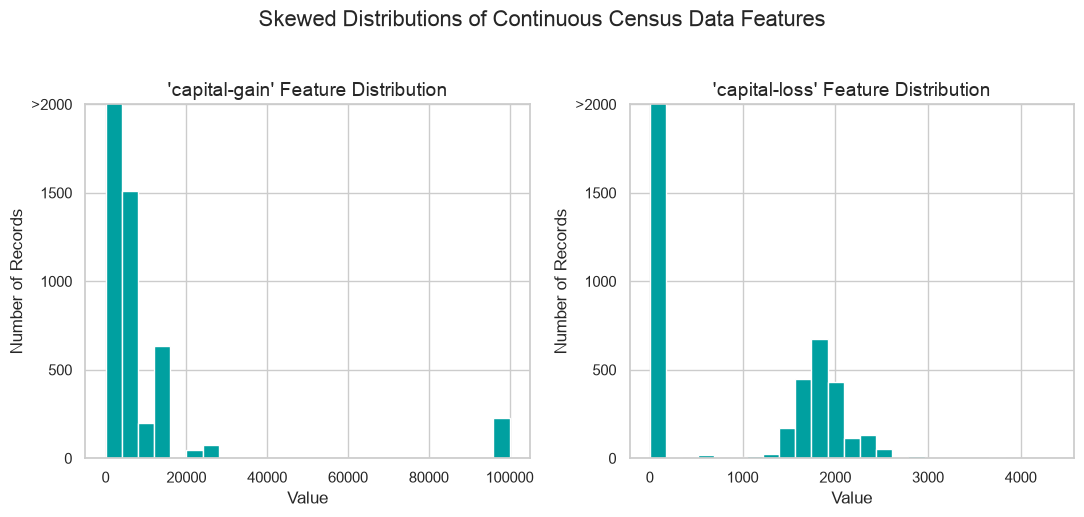

In [7]:
# Visualise skewed continuous features of original data
vs.distribution(data)

For highly-skewed feature distributions such as `'capital-gain'` and `'capital-loss'`, it is common practice to apply a <a href="https://en.wikipedia.org/wiki/Data_transformation_(statistics)">logarithmic transformation</a> on the data so that the very large and very small values do not negatively affect the performance of a learning algorithm. Using a logarithmic transformation significantly reduces the range of values caused by outliers. 

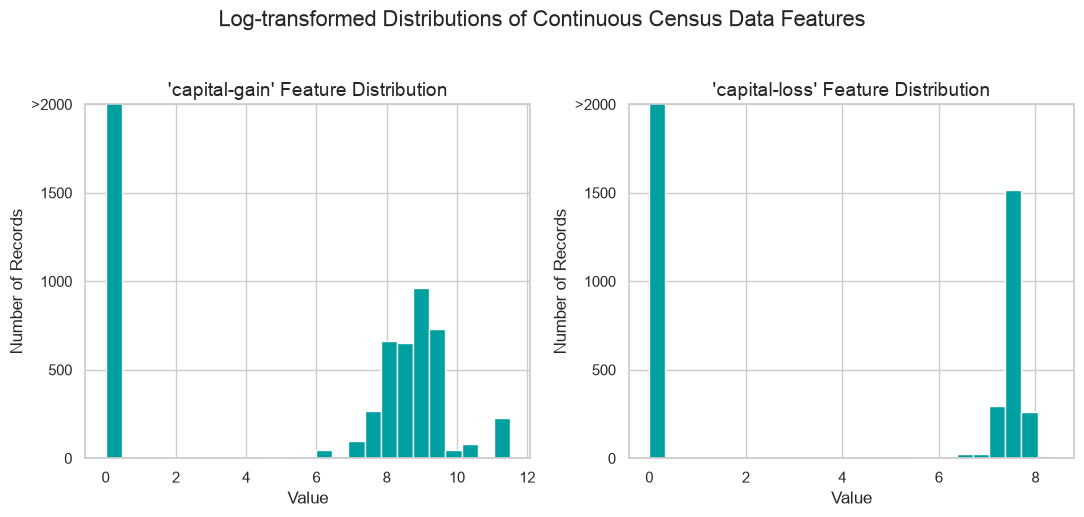

In [8]:
# Log-transform the skewed features ['capital-gain', 'capital-loss']
skewed = ["capital-gain", "capital-loss"]
features[skewed] = features[skewed].apply(lambda x: np.log(x + 1))

# Visualise the new log distributions
vs.distribution(features, transformed=True)

### Data Preprocessing

From the table in **Exploring the Data** above, we can see there are several features for each record that are non-numeric. Typically, learning algorithms expect input to be numeric, which requires that non-numeric features (called *categorical variables*) be converted. One popular way to convert categorical variables is by using the **one-hot encoding** scheme. One-hot encoding creates a _"dummy"_ variable for each possible category of each non-numeric feature. 

Additionally, as with the non-numeric features, we need to convert the non-numeric target label, `'income'` to numerical values for the learning algorithm to work. Since there are only two possible categories for this label ("<=50K" and ">50K"), we can avoid using one-hot encoding and simply encode these two categories as `0` and `1`, respectively.

In [9]:
# One-hot encode the 'features' data using pandas.get_dummies()
features = pd.get_dummies(features)

# Encode the 'income'/'target' data to numerical values
target = target.apply(lambda x: 1 if x == ">50K" else 0)

# Print the number of features after one-hot encoding
encoded = list(features.columns)
print ("{} total features after one-hot encoding.".format(len(encoded)))

103 total features after one-hot encoding.


### Shuffle and Split Data

Now all _categorical variables_ have been converted into numerical features. We will now split the data (both features and their labels) into training and test sets. 80% of the data will be used for training and 20% for testing.  

In [10]:
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=0
)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 36177 samples.
Testing set has 9045 samples.


### Normalising Numerical Features
It is often good practice to perform some type of scaling on numerical features. Applying a scaling to the data does not change the shape of each feature's distribution (such as `'capital-gain'` or `'capital-loss'` above); however, normalisation ensures that each feature is treated equally when applying supervised learners. Note that once scaling is applied, observing the data in its raw form will no longer have the same original meaning, as exampled below. To avoid data leakage we will normalise the data after we split it into train and test set. 

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Initialise a scaler, then apply it to the features
scaler = MinMaxScaler()
numerical = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
X_train[numerical] = scaler.fit_transform(X_train[numerical])
X_test[numerical] = scaler.transform(X_test[numerical])

# Show an example of a record with scaling applied
X_train[numerical].sample(1)

,age,education-num,capital-gain,capital-loss,hours-per-week
3865,0.09589,0.333333,0.0,0.0,0.489796


----
## Evaluating Model Performance
In this section, we will investigate four different algorithms, and determine which is best at modelling the data. 

### Metrics and the Naive Predictor

*CharityML*, equipped with their research, knows individuals that make more than \$50,000 are most likely to donate to their charity. Because of this, *CharityML* is particularly interested in predicting who makes more than \$50,000 accurately. It would seem that using **accuracy** as a metric for evaluating a particular model's performance would be appropriate. Additionally, identifying someone that *does not* make more than \$50,000 as someone who does would be detrimental to *CharityML*, since they are looking to find individuals willing to donate. Therefore, a model's ability to precisely predict those who make more than \$50,000 is *more important* than its ability to **recall** those individuals. We can use **F-beta score** as a metric that considers both precision and recall:

$$ F_{\beta} = (1 + \beta^2) \cdot \frac{precision \cdot recall}{\left( \beta^2 \cdot precision \right) + recall} $$

In particular, when $\beta = 0.5$, more emphasis is placed on precision.

Looking at the distribution of classes (those who make at most \$50,000, and those who make more), it's clear most individuals do not make more than \$50,000. This can greatly affect **accuracy**, since we could simply say "*this person does not make more than \$50,000*" and generally be right, without ever looking at the data! Making such a statement would be called **naive**, since we have not considered any information to substantiate the claim. It is always important to consider the *naive prediction* for your data, to help establish a benchmark for whether a model is performing well. That said, using that prediction would be pointless: If we predicted all people made less than \$50,000, *CharityML* would identify no one as donors. 

### Naive Predictor Performance

What if we chose a model that always predicted an individual made more than \$50,000, what would that model's accuracy and F-score be on this dataset? (Remember what you calculated at the beginning of the notebook.)

In [12]:
# TODO: Calculate accuracy
accuracy = n_greater_50k / n_records

# TODO: Calculating precision
precision = n_greater_50k / (n_greater_50k + n_at_most_50k)

# TODO: Calculating recall
recall = n_greater_50k / (n_greater_50k + 0)

# TODO: Calculate F-score using the formula above for beta = 0.5
fscore = (1 + 0.5**2) * (precision * recall) / ((0.5**2 * precision) + recall)

# Print the results 
print ("Naive Predictor: [Accuracy score: {:.4f}, F-score: {:.4f}]".format(accuracy, fscore))

Naive Predictor: [Accuracy score: 0.2478, F-score: 0.2917]


##  Supervised Learning Models

###  Model Application

Now we'll pick two supervised learning models above that are appropriate for this problem, and test them on the census data. 

**Decision Trees**

 - Real world application: Decision Trees and, in general, CART (Classification and Regression Trees) are often used in financial analysis. A concrete example is predicting which stocks to buy based on past performance. [Reference](https://ir.nctu.edu.tw/bitstream/11536/11962/1/000237645100007.pdf)
 - Strengths: 
      - Able to handle categorical and numerical data.
      - Doesn't require much data pre-processing, and can handle data that hasn't been normalised or encoded for machine-learning suitability.
      - Simple to understand and interpret.
 - Weaknesses:
     - Complex decision trees do not generalise well to the data and can result in overfitting.
     - Unstable, as small variations in the data can result in a different decision tree. Hence they are usually used in an ensemble (like Random Forests) to build robustness.
     - Can create biased trees if some classes dominate.
 - Candidacy: Since a decision tree can handle both numerical and categorical data, it's a good candidate for our case (although the pre-processing steps might already mitigate whatever advantage we would have had). It's also easy to interpret, so we will know what happens under the hood to interpret the results.


**Ensemble methods: AdaBoost**

 - Real world application: Ensemble methods are used extensively in Kaggle competitions, especially in image detection. A real-world example of AdaBoost is object detection in images, for example identifying players during a basketball game. [Reference](https://uni-obuda.hu/journal/Markoski_Ivankovic_Ratgeber_Pecev_Glusac_57.pdf)
 - Strengths: 
     - Ensemble methods, including AdaBoost, are more robust than single estimators and have improved generalisability. 
     - Simple models can be combined to build a complex model that remains computationally fast. 
 - Weaknesses:
     - If we have a biased underlying classifier, it will lead to a biased boosted model.
 - Candidacy: Ensemble methods are considered high-quality classifiers, and AdaBoost is one of the most popular boosting algorithms. We also have a class imbalance in our dataset, which boosting might handle robustly.


In [13]:
# Import necessary metrics and models
from sklearn.metrics import confusion_matrix
from sklearn.metrics import fbeta_score, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

### Train and Compare the Models

In the next step we will train, evaluate and compare different models. You can decide if you want to write the code several times or if you want to do it in a nicer way by defining a function that does the work for you. 

In [14]:
# Train a decision tree and an AdaBoostClassifier on the train data
clf_A = DecisionTreeClassifier(random_state=101)
clf_B = AdaBoostClassifier(random_state=101)

clf_A.fit(X_train, y_train)
clf_B.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",101
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.25,0.24,0.3 ,...,0.48,0.49,0.49]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.1 ,1.14,0.86,...,0.09,0.05,0.05]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...tate=70431583), DecisionTreeC...ate=225658379), DecisionTreeC...ate=303514961), DecisionTreeC...te=1944264518), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](103,)","[0.1 ,0.12,0.31,...,0. ,0. ,0. ]"


### Model Evaluation

Now we can evaluate the performance of our models using the accuracy and the f-1 score as well as visualise the confusion matrix for the results.

In [15]:
# Evaluate the different models comparing the accuracy and the f1-score
for clf in (clf_A, clf_B):
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = fbeta_score(y_test, preds, beta=1)
    print(f"{clf.__class__.__name__:22s} accuracy: {acc:.4f}  f1: {f1:.4f}")

DecisionTreeClassifier accuracy: 0.8174  f1: 0.6204
AdaBoostClassifier     accuracy: 0.8483  f1: 0.6495


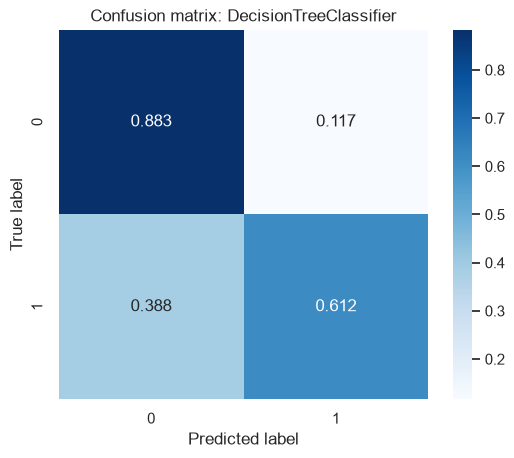

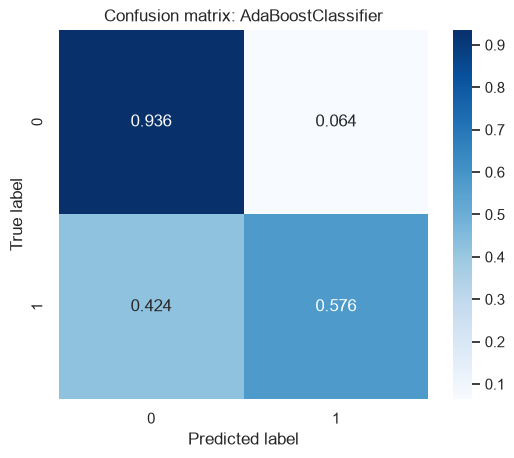

In [16]:
# Visualise the confusion matrix for each classifier
for clf in (clf_A, clf_B):
    cm = confusion_matrix(y_test, clf.predict(X_test))
    cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure()
    sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", square=True)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"Confusion matrix: {clf.__class__.__name__}")
plt.show()

### Model Tuning
Using grid search (`GridSearchCV`) with different parameter/value combinations, we can tune our model for even better results. We will tune the AdaBoostClassifier since it showed the best performance. 
For AdaBoost, we'll tune the n_estimators and learning rate parameters, and also the base classifier parameters (remember our base classifier for the AdaBoost ensemble is a decision tree!).

In [17]:
# Import 'GridSearchCV', 'make_scorer', and any other necessary libraries
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

# Initialise the classifier
clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42,
)

# Create the parameters list you wish to tune
parameters = {
    "n_estimators": [50, 120],
    "learning_rate": [0.1, 0.5, 1.0],
    "estimator__min_samples_split": np.arange(2, 8, 2),
    "estimator__max_depth": np.arange(1, 4, 1),
}

# Make an fbeta_score scoring object
scorer = make_scorer(fbeta_score, beta=0.5)

# Perform grid search on the classifier using 'scorer' as the scoring method
grid_obj = GridSearchCV(clf, parameters, scoring=scorer, n_jobs=-1)

# Fit the grid search object to the training data and find the optimal parameters
grid_fit = grid_obj.fit(X_train, y_train)

# Get the best estimator
best_clf = grid_fit.best_estimator_
# Make predictions using the un-optimised model
predictions = clf.fit(X_train, y_train).predict(X_test)
# Make predictions using the optimised model
best_predictions = best_clf.predict(X_test)

# Report the before-and-after scores
print("Un-optimized model\n------")
print(
    "Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, predictions))
)
print(
    "F-score on testing data: {:.4f}".format(fbeta_score(y_test, predictions, beta=0.5))
)
print("\nOptimized Model\n------")
print(
    "Final accuracy score on the testing data: {:.4f}".format(
        accuracy_score(y_test, best_predictions)
    )
)
print(
    "Final F-score on the testing data: {:.4f}".format(
        fbeta_score(y_test, best_predictions, beta=0.5)
    )
)
print(best_clf)

Un-optimized model
------
Accuracy score on testing data: 0.8310
F-score on testing data: 0.6535

Optimized Model
------
Final accuracy score on the testing data: 0.8544
Final F-score on the testing data: 0.7195
AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=np.int64(3),
                                                    min_samples_split=np.int64(6),
                                                    random_state=42),
                   learning_rate=0.5, n_estimators=120, random_state=42)
